# 05 - Evaluation: CatBoost di Holdout Test Set

Tahap ini menguji model final (CatBoost) pada 20% data yang di-freeze sejak awal
project (`test_ids` di `holdout_split.json`) — data ini TIDAK PERNAH dipakai selama
CV maupun training, sehingga hasilnya mencerminkan performa jujur di data baru.

Evaluasi dijalankan **satu kali saja**. Tidak boleh mengulang/tuning berdasarkan
hasil di sini, karena akan membuat data test kehilangan fungsinya sebagai pengukur
objektif (data leakage metodologis).

# Import & Setup

In [1]:
import sys
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))

from modeling.train import (
    load_featured_dataset, load_feature_metadata,
    create_or_load_holdout_split, create_or_load_cv_folds,
)
from modeling.evaluate import (
    load_final_pipeline, load_holdout_test_set, evaluate_on_holdout,
    plot_roc_pr_curves, plot_confusion_matrix_heatmap,
    compute_shap_values, plot_shap_summary, save_evaluation_report,
)

## Load Data, Metadata, Split, dan Model Final

Memuat dataset featured, metadata fitur, holdout split (untuk ambil `test_ids`),
dan pipeline CatBoost yang sudah dilatih & disimpan di tahap Modeling.

In [2]:
df = load_featured_dataset()
metadata = load_feature_metadata()
split = create_or_load_holdout_split(df)
folds = create_or_load_cv_folds(df, split)

MODEL_NAME = "catboost"
feature_list = metadata["tree_features"]

final_pipeline = load_final_pipeline(MODEL_NAME)
X_test, y_test = load_holdout_test_set(df, split, feature_list)

print("Jumlah baris holdout test:", len(X_test))
print("Proporsi TARGET=1 di holdout test:", y_test.mean())

Jumlah baris holdout test: 61503
Proporsi TARGET=1 di holdout test: 0.08072776937710356


## Evaluasi di Holdout Test Set (Sekali Saja)

Menjalankan prediksi dan menghitung ROC-AUC, PR-AUC, precision, recall, F1, dan
confusion matrix pada threshold 0.5 — metrik yang sama seperti dipakai konsisten
sejak tahap CV.

In [3]:
holdout_metrics = evaluate_on_holdout(final_pipeline, X_test, y_test, threshold=0.5)

print("Holdout ROC-AUC :", round(holdout_metrics["roc_auc"], 4))
print("Holdout PR-AUC  :", round(holdout_metrics["pr_auc"], 4))
print("Precision       :", round(holdout_metrics["precision"], 4))
print("Recall          :", round(holdout_metrics["recall"], 4))
print("F1-Score        :", round(holdout_metrics["f1"], 4))
print("Confusion Matrix:", holdout_metrics["confusion_matrix"])

Holdout ROC-AUC : 0.7637
Holdout PR-AUC  : 0.2551
Precision       : 0.1718
Recall          : 0.6733
F1-Score        : 0.2737
Confusion Matrix: [[40420, 16118], [1622, 3343]]


## Visualisasi: ROC Curve, PR Curve, dan Confusion Matrix

Grafik ini disimpan otomatis ke `reports/figures/` untuk dipakai di README/laporan.

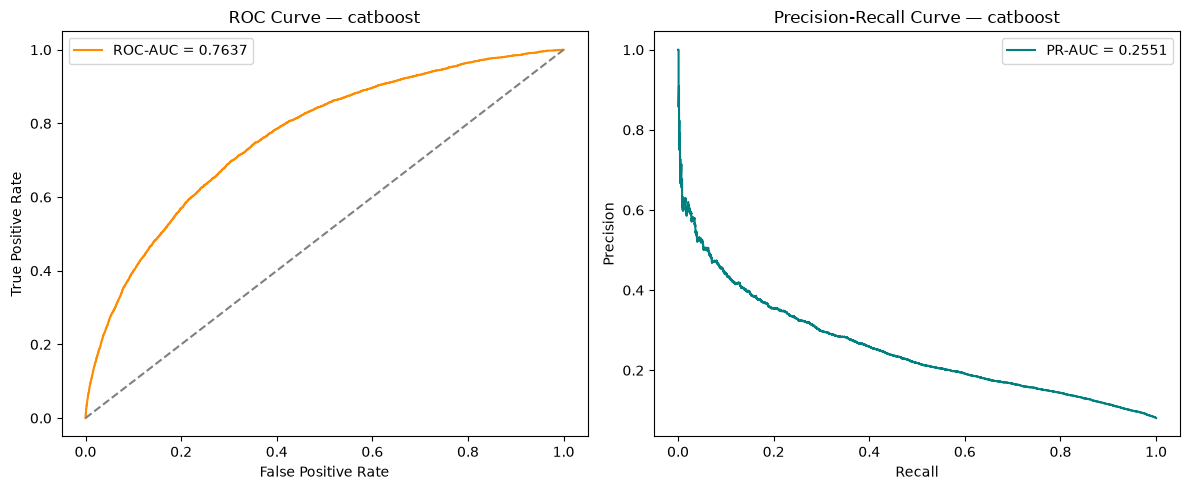

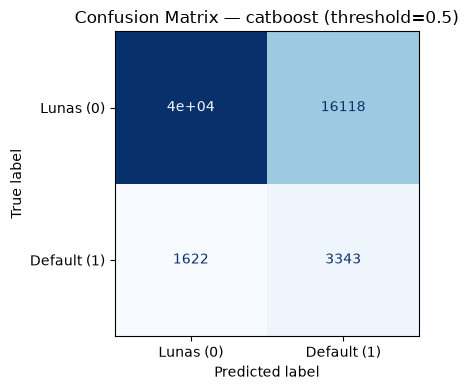

WindowsPath('D:/Kerjaan/Home Creadit/Project-1-Home-Credit-Default-Risk-main/reports/figures/catboost_confusion_matrix.png')

In [4]:
plot_roc_pr_curves(
    y_test, holdout_metrics["y_test_proba"], MODEL_NAME,
    roc_auc=holdout_metrics["roc_auc"], pr_auc=holdout_metrics["pr_auc"],
)

plot_confusion_matrix_heatmap(
    y_test, holdout_metrics["y_test_proba"], MODEL_NAME, threshold=0.5,
)

## Interpretasi Model dengan SHAP

SHAP (SHapley Additive exPlanations) menjelaskan fitur mana yang paling
mempengaruhi prediksi model, dan ke arah mana (menaikkan atau menurunkan
probabilitas gagal bayar). Dihitung dari sampel 2000 baris holdout test.

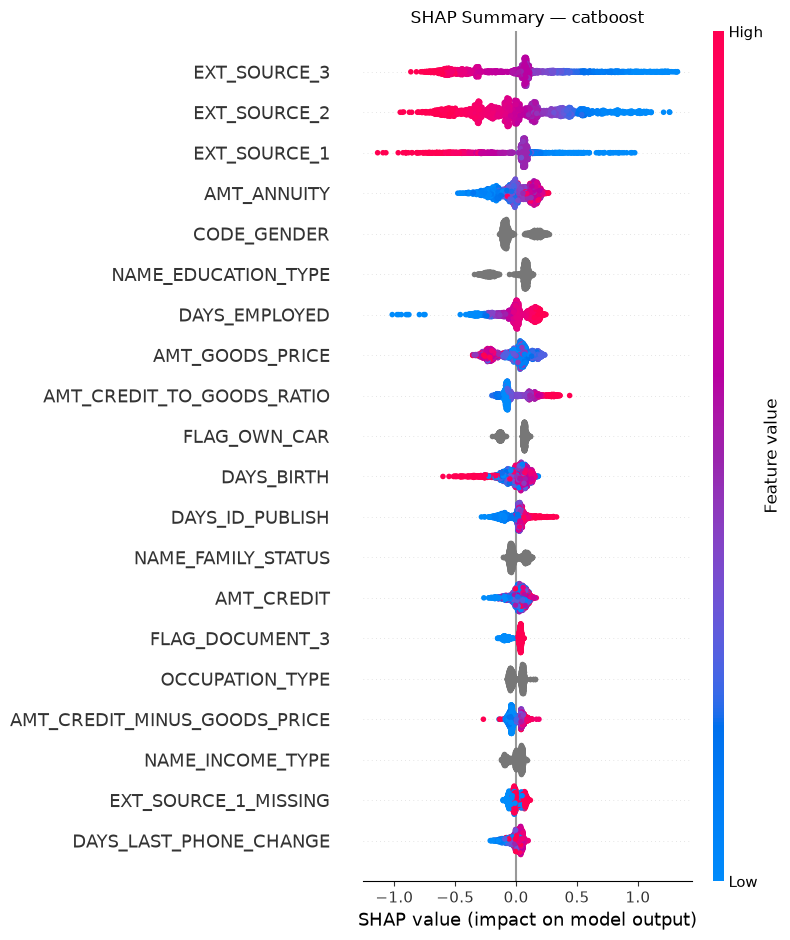

WindowsPath('D:/Kerjaan/Home Creadit/Project-1-Home-Credit-Default-Risk-main/reports/figures/catboost_shap_summary.png')

In [5]:
shap_values, X_shap_sample = compute_shap_values(final_pipeline, X_test, sample_size=2000)
plot_shap_summary(shap_values, X_shap_sample, MODEL_NAME)

## Simpan Laporan Evaluasi Final

Menyimpan seluruh metrik holdout test ke
`models/catboost/catboost_holdout_metrics.json` sebagai bukti hasil final v1.

In [6]:
report_path = save_evaluation_report(holdout_metrics, MODEL_NAME)
print("Laporan evaluasi tersimpan di:", report_path)

Laporan evaluasi tersimpan di: D:\Kerjaan\Home Creadit\Project-1-Home-Credit-Default-Risk-main\models\catboost\catboost_holdout_metrics.json
